### Validating the formula used by `calc_nft_mode_freqs()` against `sim_nft_waves()`
Here, we show that the damped harmonic oscillator formula used by `calc_nft_mode_freqs()`
($f_j=\frac{r \gamma}{2 \pi}\sqrt{\lambda_j}$) correctly predicts mode $j$'s frequency (in Hz) when
simulated as an ODE system via `sim_nft_waves()`.

To illustrate damping in the wave model, we will set each mode's input to a constant 1 for a second,
then simulate another second, allowing activity to rise and fall with oscillations (*Figure 1*).

Using the Fourier transform on the simulated timeseries lets us see each mode's power spectrum
across frequencies (*Figure 2*) and compare the most prominant frequency to the theoretical
prediction.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from neuromodes import EigenSolver
from neuromodes.io import fetch_example_surf
from neuromodes.waves import calc_nft_mode_freqs


In [2]:
# Set parameters
n_modes = 200
modes_plotted = [1, 10, 50, n_modes]
r = 50
gamma = 10
dt = 1e-3  # s
t = 2.0  # s
nt = round(t / dt)
t0 = nt // 2

In [3]:
# Solve for eigenmodes and eigenvalues of a cortical surface (fsLR 4k, left hemisphere)
surf, medmask = fetch_example_surf(density='4k')
solver = EigenSolver(surf, medmask).solve(n_modes, decomp='cholesky')

In [4]:
# Set each mode's input to 1 from 0 to t0
ext_input = np.zeros((solver.n_verts, nt))
ext_input[:, :t0] = solver.emodes.sum(axis=1)[:, None]

In [5]:
# Simulate wave model as ODE system per mode, then decompose to modal basis
sim_ts = solver.sim_nft_waves(ext_input=ext_input, r=r, gamma=gamma, dt=dt, method='ode')
sim_ts = solver.decompose(sim_ts)

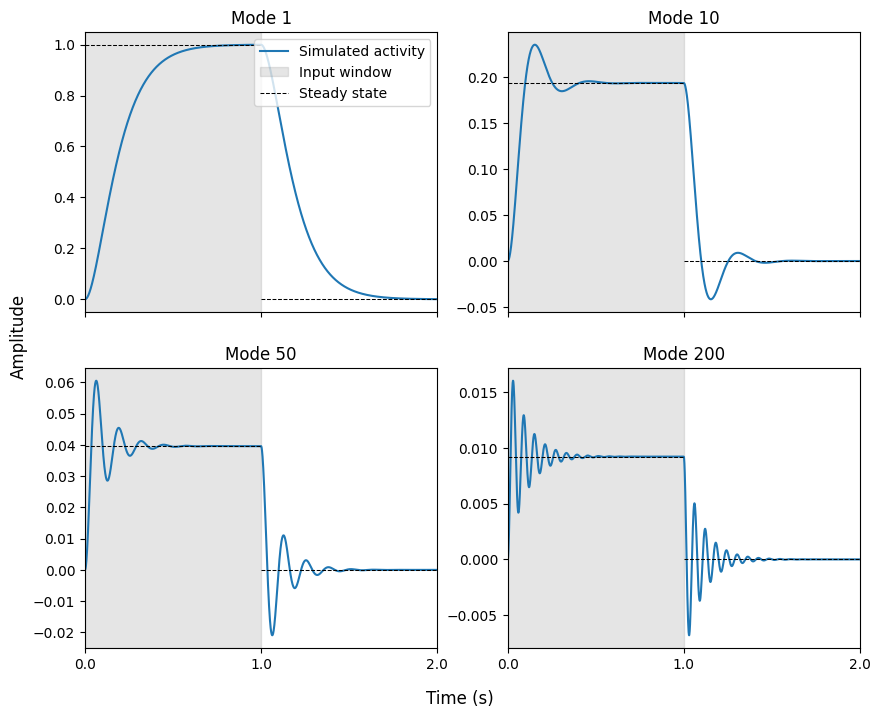

In [6]:
# Visualise simulated activity for a few modes
xticks = np.array([0, t0, nt])
steady_state = 1/(1+r**2 * solver.evals)

fig, axs = plt.subplots(2, 2, figsize=(10, 8), sharex=True)
for i, idx in enumerate(modes_plotted):
    row = i // 2
    col = i % 2
    axs[row, col].plot(sim_ts[idx-1, :], label='Simulated activity')
    axs[row, col].axvspan(0, t0, color='gray', alpha=0.2, label='Input window')
    axs[row, col].axhline(y=steady_state[idx-1], xmax=0.5, color='k', linestyle='--',
                          linewidth=0.75, label='Steady state')
    axs[row, col].axhline(y=0, xmin=0.5, color='k', linestyle='--', linewidth=0.75)
    axs[row, col].set_title(f'Mode {idx}')
    axs[row, col].set_xlim(0, nt)
    axs[row, col].set_xticks(xticks)
    axs[row, col].set_xticklabels(xticks * dt)
axs[0, 0].legend(loc='upper right')
fig.text(0.5, 0.04, 'Time (s)', ha='center', fontsize=12)
fig.text(0.05, 0.5, 'Amplitude', va='center', rotation='vertical', fontsize=12)
plt.show()

In [7]:
# Detect frequencies from latter half of timeseries via FFT
# NOTE: first half could be used too, but the steady state (DC component) needs to be removed by
# subtracting 1/(1 + r**2 * evals) (sim_ts[:, t0-1] should approximate this, indicating the system has
# approached steady state), otherwise dominant frequency will be 0 Hz
sim_fft = np.abs(np.fft.rfft(sim_ts[:, t0:], axis=1))**2
freqs_fft = np.fft.rfftfreq(t0, dt)

# Calculate theoretical mode frequencies
freqs_theo = calc_nft_mode_freqs(solver.evals, r=r, gamma=gamma)

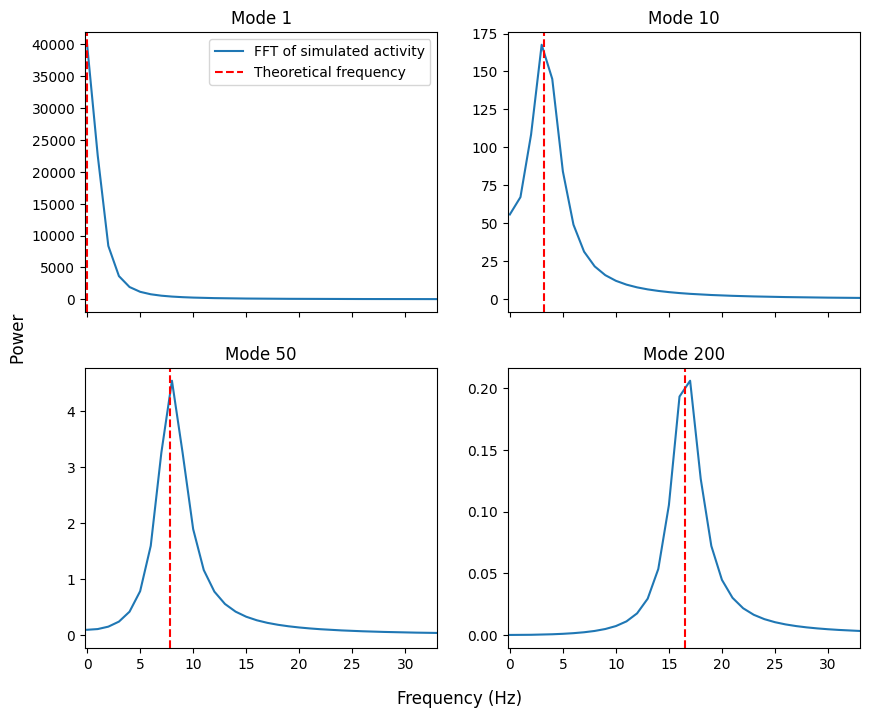

In [8]:
# Visualise each mode's detected and theoretical frequencies
fig, axs = plt.subplots(2, 2, figsize=(10, 8), sharex=True)
xmax = 2*np.max(freqs_theo)

for i, idx in enumerate(modes_plotted):
    row = i // 2
    col = i % 2
    axs[row, col].plot(freqs_fft, sim_fft[idx-1, :], label='FFT of simulated activity')
    axs[row, col].axvline(x=freqs_theo[idx-1], color='r', linestyle='--', label='Theoretical frequency')
    axs[row, col].set_title(f'Mode {idx}')
    axs[row, col].set_xlim(-0.2, xmax)
axs[0, 0].legend(loc='upper right')
fig.text(0.5, 0.04, 'Frequency (Hz)', ha='center', fontsize=12)
fig.text(0.05, 0.5, 'Power ', va='center', rotation='vertical', fontsize=12)
plt.show()

In [9]:
# Get each mode's highest-power frequency from FFT of simulated activity
freqs_detected = freqs_fft[np.argmax(sim_fft, axis=1)]

# Check that each mode's detected frequency is within 1 FFT bin of its theoretical frequency
bin_width = freqs_fft[1] - freqs_fft[0]
np.testing.assert_allclose(
    freqs_detected,
    freqs_theo,
    atol=bin_width,
    err_msg="Detected frequencies do not match theoretical frequencies within 1 FFT bin"
    )